In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# I. GD

<!-- **Gradient Descent** là một thuật toán tối ưu hóa cơ bản được sử dụng trong machine learning nhằm tìm ra điểm cực tiểu của một hàm số. Thuật toán này hoạt động bằng cách lặp đi lặp lại việc di chuyển theo hướng giảm dốc nhất của hàm, tức là hướng ngược lại với gradient của hàm số đó. Cơ chế này khiến nó trở nên đặc biệt hữu ích trong quá trình training các mô hình machine learning.


- **Gradient** của một hàm số: Khái niệm Gradient là sự mở rộng của derivative dành cho các hàm nhiều biến. Đối với một hàm $f(x, y, z, ...)$, gradient, ký hiệu là $\nabla f$ hoặc `grad` f, là một vector chỉ về hướng mà hàm số có sự tăng trưởng dốc nhất. Trong không gian ba chiều, nó được biểu diễn dưới dạng $∇f = (∂f/∂x, ∂f/∂y, ∂f/∂z)$. Mỗi thành phần của vector gradient này là một đạo hàm riêng của hàm số theo một trong các biến của nó, thể hiện sự thay đổi của hàm số khi biến cụ thể đó thay đổi, trong khi các biến còn lại được giữ nguyên và được coi như hằng số.


Trong toán học và tối ưu hóa , gradient của một hàm số là một vector bao gồm các đạo hàm riêng của hàm số đó theo từng biến. Nó biểu diễn:

- Đối với hàm một biến: Độ dốc (slope) của hàm số tại một điểm cụ thể.

- Đối với hàm nhiều biến: Độ dốc trong từng chiều không gian . -->

## 1. Khái niệm Gradient (Nền tảng Toán học)

Trong giải tích và tối ưu hóa, Gradient (ký hiệu là $\nabla f$ hoặc $\text{grad} f$) là sự mở rộng khái niệm đạo hàm dành cho các hàm nhiều biến. Cụ thể, nó là một vector bao gồm các đạo hàm riêng của hàm số đó theo từng biến.

Về mặt hình học, Gradient mang ý nghĩa cực kỳ quan trọng:
-  Chỉ hướng tăng dốc nhất: Vector Gradient luôn chỉ về hướng mà giá trị của hàm số tăng lên nhanh nhất.

-  Với hàm một biến: Nó chính là độ dốc (slope) của hàm số tại một điểm cụ thể.'

-  Hàm nhiều biến: Nó thể hiện độ dốc tổng hợp trong từng chiều không gian. Ví dụ, với một hàm trong không gian ba chiều $f(x, y, z)$, gradient được biểu diễn dưới dạng:
$$
\nabla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z} \right)
$$

(Lưu ý: Mỗi thành phần trong vector này là một đạo hàm riêng, cho biết hàm số thay đổi ra sao khi chỉ một biến thay đổi, trong khi các biến còn lại được xem như hằng số).


## 2. Thuật toán Gradient Descent (Ứng dụng trong Machine Learning)

Hiểu được bản chất của Gradient, chúng ta có thể áp dụng nó vào Gradient Descent – một thuật toán tối ưu hóa cơ bản và mang tính cốt lõi trong Machine Learning nhằm tìm ra điểm cực tiểu của một hàm số (thường là hàm mất mát).

**Cơ chế hoạt động của nó tương đối đơn giản**: Vì vector Gradient luôn chỉ hướng hàm số tăng dốc nhất, nên để tìm điểm cực tiểu thuật toán sẽ lặp đi lặp lại việc di chuyển theo hướng ngược lại với Gradient, tức là hướng giảm dốc nhất. Quá trình này giúp mô hình liên tục điều chỉnh các tham số cho đến khi chạm đến điểm thấp nhất, khiến nó trở nên đặc biệt hữu ích trong quá trình training.



## a. Gradient Descent đơn biến

In [2]:
def f_1d(x):
    return x**2

def gradient_1d(x):
    return 2 * x

def simple_1dGD(x, lr, epochs):
    x_path = [x]
    current_x = x

    for _ in range(epochs):
        grad = gradient_1d(current_x)
        current_x = current_x - lr * grad
        x_path.append(current_x)

    return np.array(x_path)

In [3]:
def plot_1dGD(x, y):

    x_vals = np.linspace(-5, 5, 100)
    y_vals = f_1d(x_vals)

    # setup figure
    plt.figure(figsize=(10,6))
    plt.plot(x_vals, y_vals, label=r'$f(x) = x^2$', color='blue', alpha=0.6)

    plt.plot(x, y, 'ro-', markersize=6)
    plt.plot(x[0], y[0], 'ko', label='initial', markersize=8)
    plt.plot(x[-1], y[-1], 'go', label='end', markersize=8)
    plt.plot(0, 0, 'y*', markersize=20, markeredgecolor='black', label='Optima')

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

[4.         3.2        2.56       2.048      1.6384     1.31072
 1.048576   0.8388608  0.67108864 0.53687091 0.42949673 0.34359738
 0.27487791 0.21990233 0.17592186 0.14073749 0.11258999 0.09007199
 0.07205759 0.05764608 0.04611686 0.03689349 0.02951479 0.02361183
 0.01888947 0.01511157]


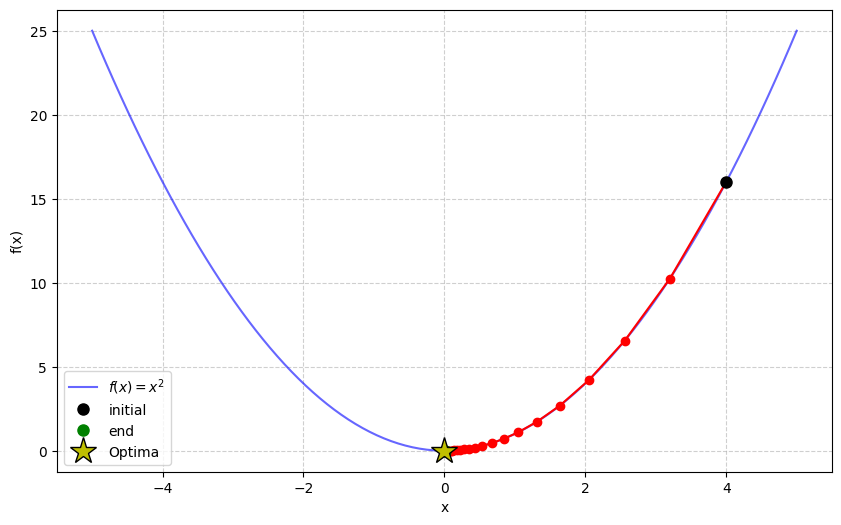

In [4]:
init_point = 4.0
lr = 0.1
epochs = 25
0
x_path = simple_1dGD(init_point, lr, epochs)
print(x_path)
y_path = f_1d(x_path)
#print(y_path)

plot_1dGD(x_path, y_path)

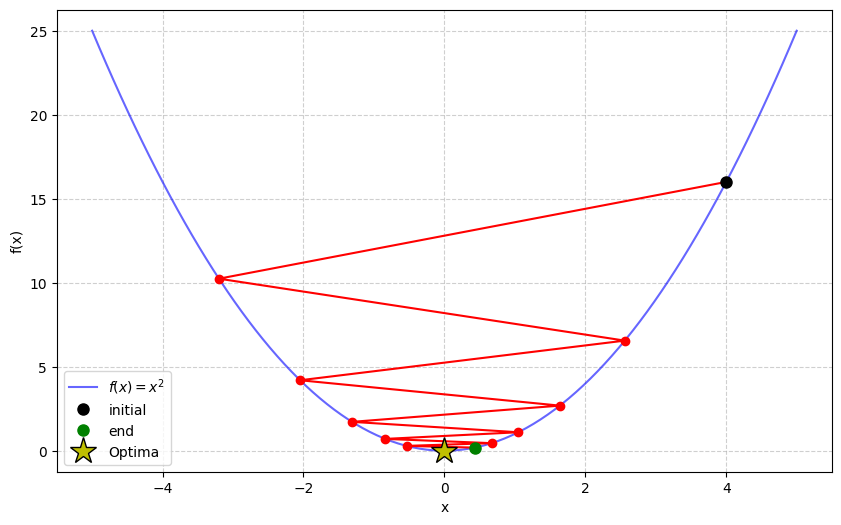

In [5]:
init_point = 4.0
lr = 0.9
epochs = 10

x_path = simple_1dGD(init_point, lr, epochs)
#print(x_path)
y_path = f_1d(x_path)
#print(y_path)

plot_1dGD(x_path, y_path)

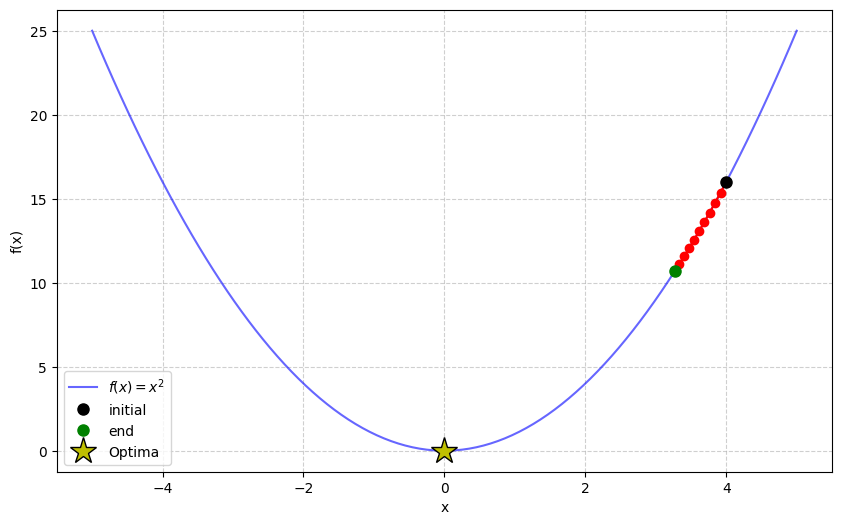

In [6]:
init_point = 4.0
lr = 0.01
epochs = 10

x_path = simple_1dGD(init_point, lr, epochs)
#print(x_path)
y_path = f_1d(x_path)
#print(y_path)

plot_1dGD(x_path, y_path)

## b. Gradient Descent cho trường hợp đa biến

In [7]:
def f2d(x, y):
    return x**2 + y**2

# gradient of multivariable
def gd2d(x, y):
    return np.array([2*x, 2*y])

def gradient_descent(start_x, start_y, learning_rate, iterations):

    path = []
    current_pos = np.array([start_x, start_y])

    for i in range(iterations):
        path.append(current_pos.copy())
        grad = gd2d(current_pos[0], current_pos[1])
        current_pos = current_pos - learning_rate * grad

        if i % 5 == 0: # for fun
            print(f"Iteration {i:2}: Pos=({current_pos[0]:.4f}, {current_pos[1]:.4f}),"
            f"f(x,y)={f2d(current_pos[0], current_pos[1]):.4f}")

    return np.array(path)

In [8]:
initial_point = (1.8, 1.6)
lr = 0.1
epochs = 25

path_history = gradient_descent(initial_point[0],
                                initial_point[1],
                                lr,
                                epochs)



Iteration  0: Pos=(1.4400, 1.2800),f(x,y)=3.7120
Iteration  5: Pos=(0.4719, 0.4194),f(x,y)=0.3986
Iteration 10: Pos=(0.1546, 0.1374),f(x,y)=0.0428
Iteration 15: Pos=(0.0507, 0.0450),f(x,y)=0.0046
Iteration 20: Pos=(0.0166, 0.0148),f(x,y)=0.0005


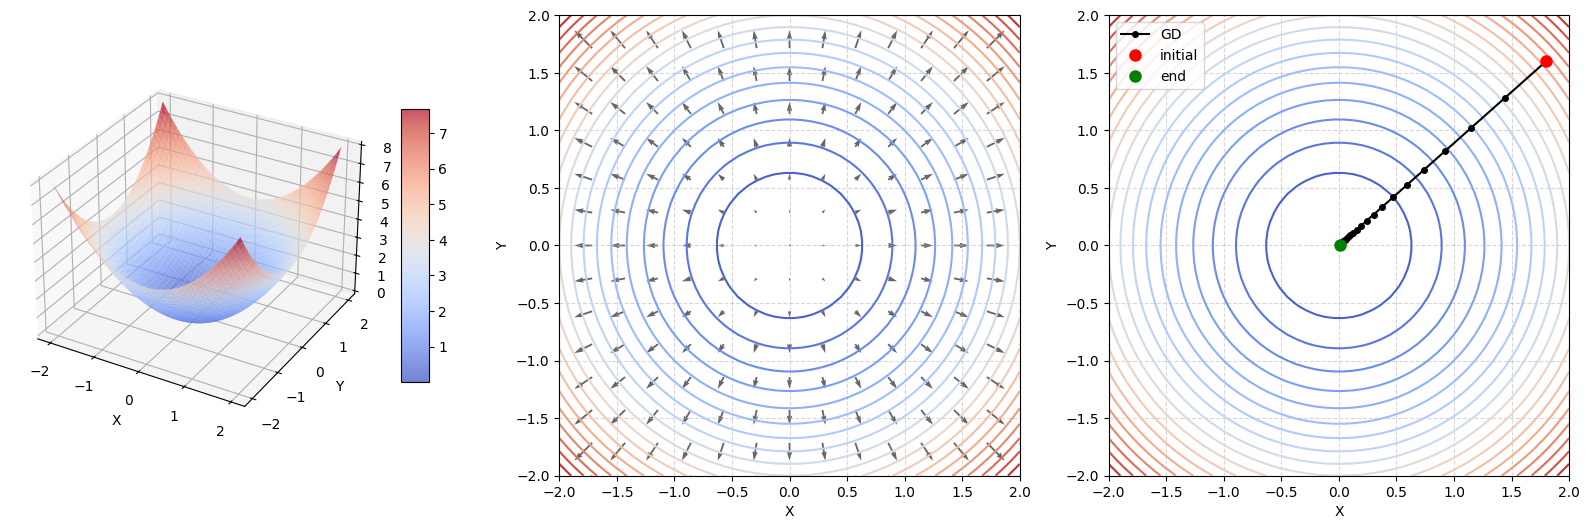

In [9]:
# Create meshgrid
nx, ny = 50, 50
x_range = np.linspace(-2, 2, nx)
y_range = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = f2d(X, Y)

# Setup figure
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap= plt.cm.coolwarm, alpha=0.7, linewidth=0)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Quiver plot
nx_q, ny_q = 15, 15
x_q = np.linspace(-2, 2, nx_q)
y_q = np.linspace(-2, 2, ny_q)
X_q, Y_q = np.meshgrid(x_q, y_q)
Grad_X, Grad_Y = gd2d(X_q, Y_q)

ax2 = fig.add_subplot(132)
ax2.contour(X, Y, Z, 20, cmap=plt.cm.coolwarm) # contour
ax2.quiver(X_q, Y_q, Grad_X, Grad_Y, color='black', alpha=0.6) # gradient arrow
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_aspect('equal')


ax3 = fig.add_subplot(133)
ax3.contour(X, Y, Z, 20, cmap=plt.cm.coolwarm)
ax3.plot(path_history[:, 0], path_history[:, 1], 'o-', color='black', markersize=4, label='GD')
ax3.plot(path_history[0, 0], path_history[0, 1], 'ro', markersize=8, label='initial')
ax3.plot(path_history[-1, 0], path_history[-1, 1], 'go', markersize=8, label='end')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_aspect('equal')
ax3.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Giả sử chúng ta có một tập dữ liệu nhỏ gồm hai vector:
- Features Vector - $X$
- Target Vector - $y$

Mục tiêu của chúng ta: Tìm một đường thẳng có phương trình $\hat{y} = w \cdot x + c$ (với $w$ là trọng số/độ dốc, và $c$ là hệ số tự do/độ lệch) sao cho đường thẳng này fit với các điểm dữ liệu trên. Chúng ta sử dụng hàm Mean Squared Error (MSE) để đo lường sai số giữa dự đoán của đường thẳng ($\hat{y}$) và giá trị thực tế ($y$):

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 = \frac{1}{N} \sum_{i=1}^{N} (y_i - (w \cdot x_i + c))^2
$$

Trong mô hình này, hàm MSE đóng vai trò là một objective function định hình không gian tối ưu hóa việc cực tiểu hóa hàm MSE tương đương với quá trình tìm kiếm điểm cực tiểu toàn cục, nơi bộ tham số $(w, c)$ mang lại sai số dự đoán thấp nhất.

In [10]:
# 1d vecs
n_samples = 20
X = np.random.uniform(0, 10, n_samples)
y = X + 1

# hyperparams
w = 0.0
c = 0.0
lr = 0.01
n = float(len(X))

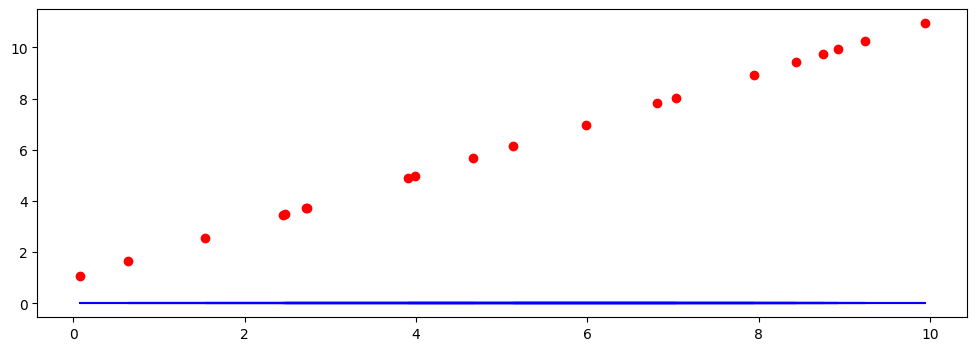

In [11]:
plt.figure(figsize=(12, 4))

plt.scatter(X, y, color='red', label='X')
plt.plot(X, w*X + c, color='blue', label='Y')

In [12]:
loss_history = []

for i in range(epochs):
    y_pred = w * X + c
    mse = (1/n) * np.sum((y - y_pred)**2)
    # print(f" Epoch {i}/{epochs} : MSE = {mse:.3f} ")
    loss_history.append(mse)

    # grad
    dw = (-2/n) * np.sum(X * (y - y_pred))
    dc = (-2/n) * np.sum(y - y_pred)

    # update new params
    w = w - lr * dw
    c = c - lr * dc



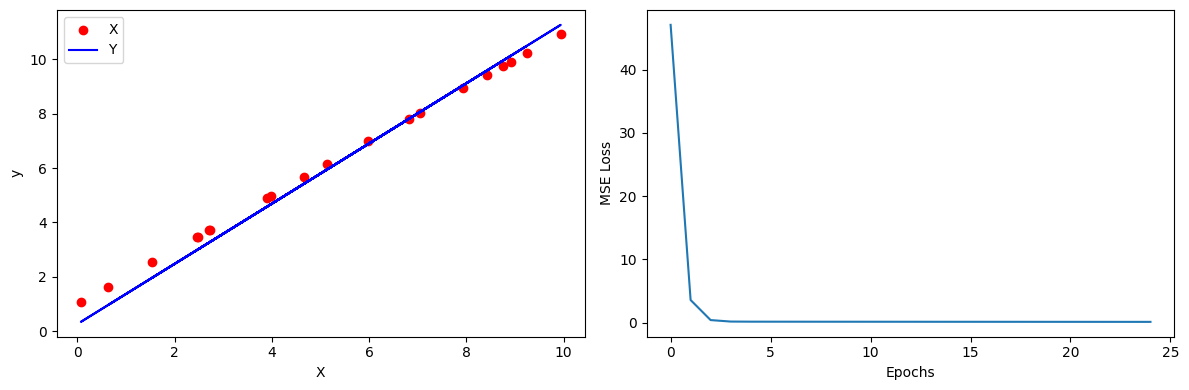

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, color='red', label='X')
plt.plot(X, w*X + c, color='blue', label='Y')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()

- Tóm lại ta có thể biểu diễn thuật toán Gradient Descent như sau:

    - **Bước 1 - Initialization:** Chọn một điểm khởi tạo (intial point) ngẫu nhiên hoặc mang tính phỏng đoán cho các tham số mà ta đang cố gắng tối ưu sau đó gán giá trị khởi tạo này là $\theta_0$. Đặt biến đếm vòng lặp $t = 0$.

    - **Bước 2 - Compute the Gradient :**  Tại bước lặp thứ $t$, tính toán gradient của loss function đối với các parameters hiện tại.Biểu thức toán học: $g_t = \nabla L(\theta_t)$

    - **Bước 3 - Update the Parameters :** Cập nhật các parameters di chuyển theo hướng ngược lại với gradient vừa tính được.Biểu thức toán học: $\theta_{t+1} = \theta_t - \alpha \cdot g_t$

    - **Bước 4: Repeat :** Kiểm tra xem thuật toán đã đạt đến trạng thái hội tụ (convergence) hay chưa. Trạng thái này thường được xác định khi:
      - Độ lớn của gradient gần như bằng 0 : $||g_t|| \le \epsilon$ hoặc hàm mất mát không còn giảm đáng kể nữa.
      
      - Nếu chưa hội tụ, tăng $t = t + 1$ và lặp lại từ Bước 2.
      
      - Nếu đã hội tụ, thuật toán dừng lại và trả về giá trị $\theta_{t+1}$ làm bộ tham số tối ưu cuối cùng.

## d. Stochastic Gradient Descent

Trong bài toán tối ưu, mục tiêu của chúng ta là tìm bộ tham số $\theta$ sao cho hàm mất mát $L$ đạt giá trị nhỏ nhất. Khác với Gradient Descent  phải tính sai số trên toàn bộ tập dữ liệu ở mỗi bước, **Stochastic Gradient Descent** (SGD) tối ưu tốc độ bằng cách cập nhật tham số ngay lập tức chỉ sau khi nhìn thấy một điểm dữ liệu ngẫu nhiên.

Về bản chât, thuật toán của SGD giống với GD, tuy nhiên ta cần phải xáo trộn dữ liệu trong mỗi lần lặp và ở bước tính Gradient ta chỉ chọn ngẫu nhiên 1 điểm dữ liệu.  $g_t = \nabla L_i(\theta_t)$

In [14]:
loss_history = []
n = len(X)

for i in range(epochs):
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    epoch_loss = 0

    for j in range(n):
        X_j = X_shuffled[j]
        y_j = y_shuffled[j]

        # loss
        y_pred_j = w * X_j + c
        epoch_loss += (y_j - y_pred_j)**2

        # grad
        dw = -2 * X_j * (y_j - y_pred_j)
        dc = -2 * (y_j - y_pred_j)

        # update
        w = w - lr * dw
        c = c - lr * dc

    mse = epoch_loss / n
    loss_history.append(mse)

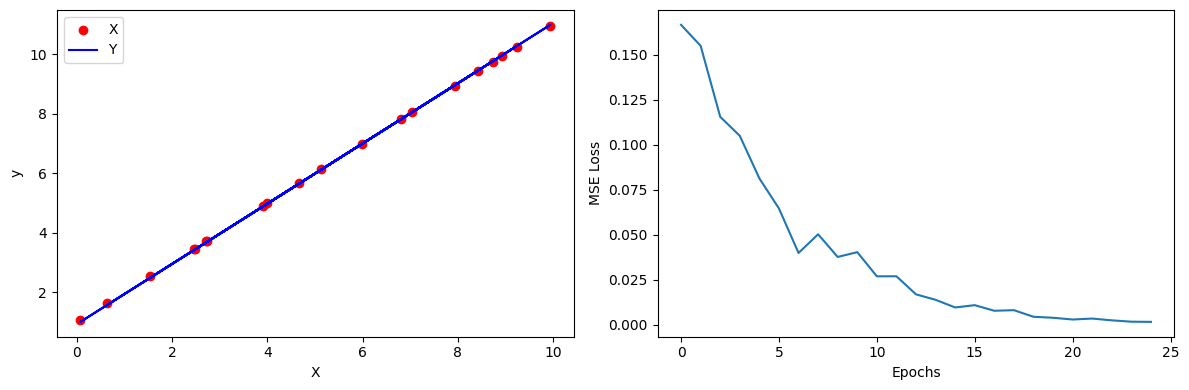

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, color='red', label='X')
plt.plot(X, w*X + c, color='blue', label='Y')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()

## c. Phương pháp Newton

Nếu như với Gradient Descent, ta chỉ cần tính đạo hàm bậc nhất thì phương pháp Newton sử dụng cả đạo hàm bậc hai và bậc nhất. Điều này là bởi đạo hàm bậc 2 cho chúng ta biết **độ cong (curvate)** của hàm số. Nhờ vậy, việc sử dụng hai bậc đạo hàm cho phép ta không chỉ biết hướng đi xuống mà còn biết được hình dáng tổng thể của hàm số đó từ đó tính toán chính xác đáy nằm ở đâu để nhảy thẳng tới đó.

Về mặt toán học, với hàm 1 biến, phương pháp Newton có thể biểu diễn dưới dạng:

$$
x_{n+1} = x_n - \frac{f'(x_n)}{f''(x_n)}
$$

Với hàm đa biến, đạo hàm bậc 1 trở thành vector Gradient ($\nabla f$), và đạo hàm bậc 2 được mở rộng thành một ma trận vuông gọi là Ma trận Hessian ($H$), lúc này công thức cập nhất của nó có dạng:

$$
x_{n+1} = x_n - H^{-1} \nabla f(x_n)
$$

In [16]:
def gradient2_1d(x):
    return 2

def simple_1dNew(x, epochs):
  x_path = [x]
  current_x = x
  for _ in range(epochs):
      grad = gradient_1d(current_x)
      hess = gradient2_1d(current_x)
      current_x = current_x - grad / hess
      x_path.append(current_x)

  return np.array(x_path)

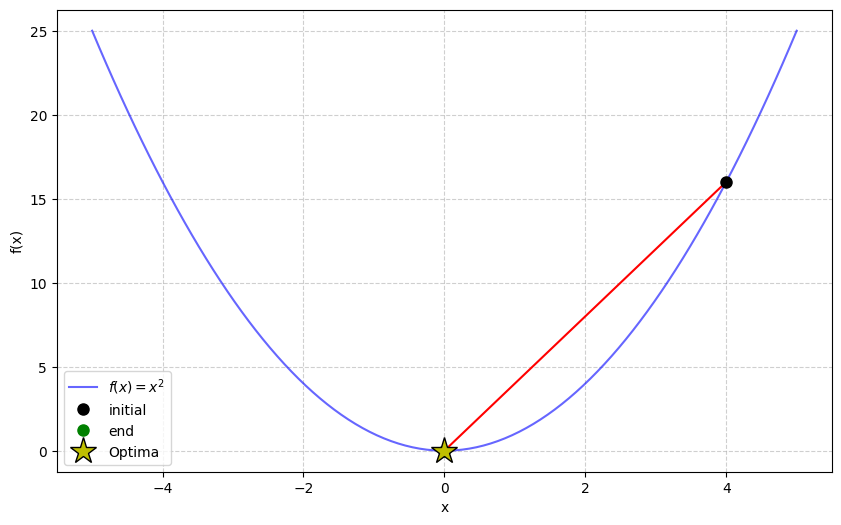

In [17]:
init_point = 4.0
epochs = 5

x_path = simple_1dNew(init_point, epochs)
#print(x_path)
y_path = f_1d(x_path)
#print(y_path)

plot_1dGD(x_path, y_path)

In [18]:
def hessian():
  return np.array([[2, 0],
                   [0, 2]])

def simple_newton2D(x, y, epochs):
    path = []
    current_pos = np.array([x, y])

    for i in range(epochs):
        path.append(current_pos)
        grad = gd2d(current_pos[0], current_pos[1])
        hess = np.linalg.inv(hessian())

        current_pos = current_pos - np.dot(hess, grad)

    return np.array(path)

initial_point = (1.8, 1.6)
lr = 0.1
epochs = 25

path_history = simple_newton2D(initial_point[0],
                                initial_point[1],
                                epochs)



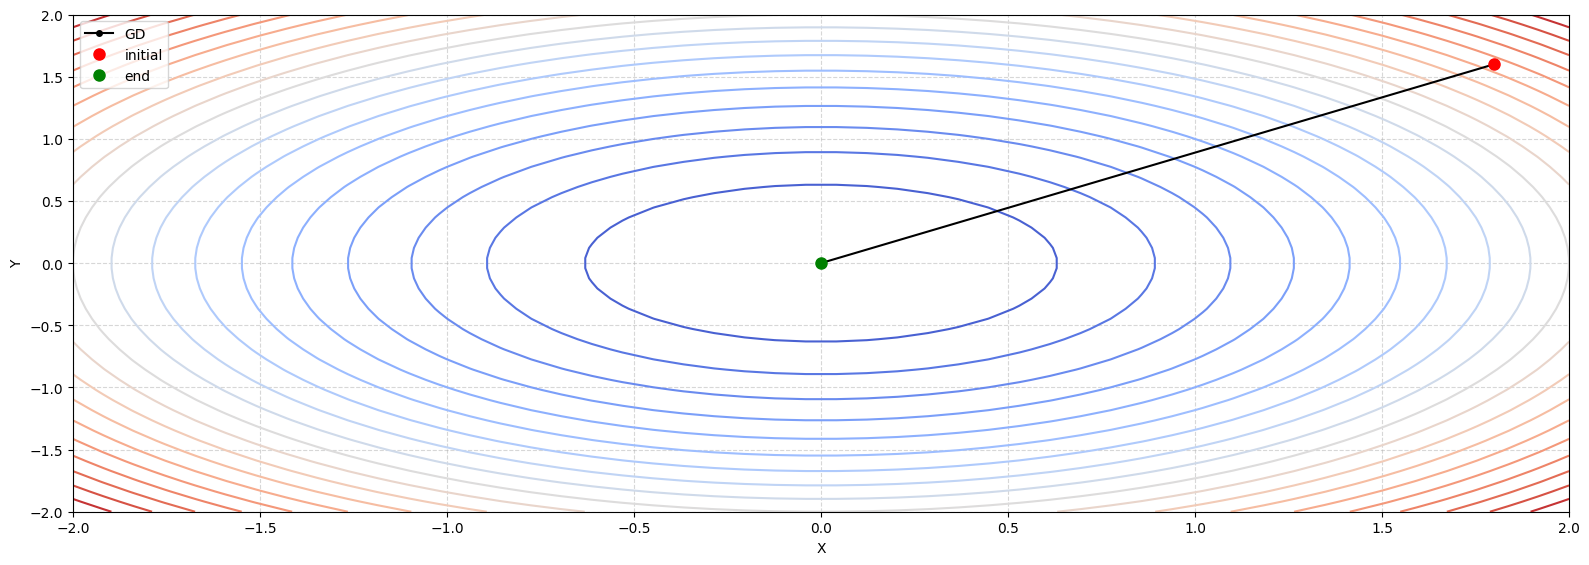

In [19]:
# Create meshgrid
nx, ny = 50, 50
x_range = np.linspace(-2, 2, nx)
y_range = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = f2d(X, Y)


fig = plt.figure(figsize=(16, 6))

plt.contour(X, Y, Z, 20, cmap=plt.cm.coolwarm)
plt.plot(path_history[:, 0], path_history[:, 1], 'o-', color='black', markersize=4, label='GD')
plt.plot(path_history[0, 0], path_history[0, 1], 'ro', markersize=8, label='initial')
plt.plot(path_history[-1, 0], path_history[-1, 1], 'go', markersize=8, label='end')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# II. Bài tập

**Câu 1:** Cho hàm số $f(x) = x^4 - 4x^3 + 2$.

- Viết hàm tính đạo hàm của $f(x)$.
- Khởi tạo `init_point = 3.5` và chạy thuật toán Gradient Descent với 3 giá trị learning rate khác nhau:  0.01, 0.05, 0.3 và `epochs = 50`.
- Vẽ đồ thị đường đi của thuật toán trong cả 3 trường hợp. Nhận xét tượng gì xảy ra với từng `lr`

In [20]:
def f(x):
    return x**4 - 4 * x**3 + 2

def gradient(x):
    return 4 * x**3 - 12 * x**2

def simple_GD(x, lr, epochs):
    x_path = [x]
    current_x = x

    for _ in range(epochs):
        grad = gradient(current_x)
        current_x = current_x - lr * grad
        x_path.append(current_x)

    return np.array(x_path)

In [21]:
def plot_GD(x, y):

    x_vals = np.linspace(-1, 4, 100)
    y_vals = f(x_vals)

    # setup figure
    plt.figure(figsize=(10,6))
    plt.plot(x_vals, y_vals, label=r'$f(x) = x^4 - 4x^3 + 2$', color='blue', alpha=0.6)

    plt.plot(x, y, 'ro-', markersize=6)
    plt.plot(x[0], y[0], 'ko', label='initial', markersize=8)
    plt.plot(x[-1], y[-1], 'go', label='end', markersize=8)
    plt.plot(3, -25, 'y*', markersize=20, markeredgecolor='black', label='Optima')

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

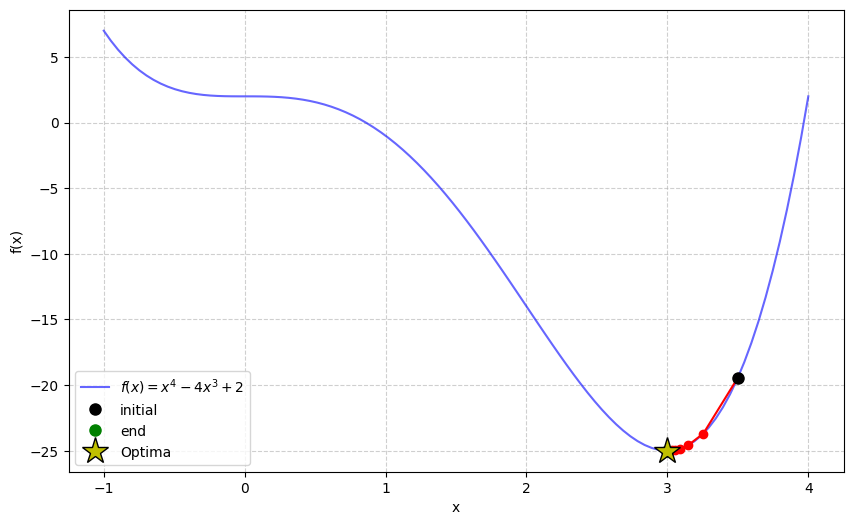

In [22]:
init_point = 3.5
lr = 0.01
epochs = 50
x_path = simple_GD(init_point, lr, epochs)
y_path = f(x_path)

plot_GD(x_path, y_path)

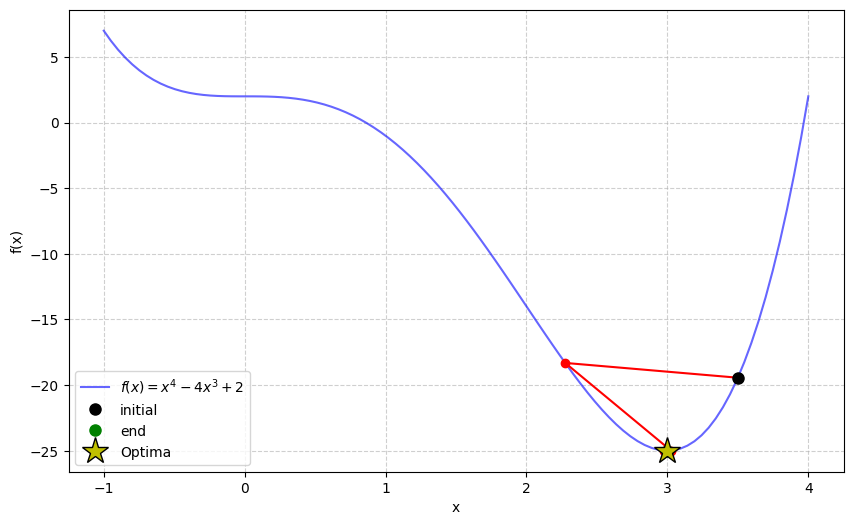

In [23]:
init_point = 3.5
lr = 0.05
epochs = 50
x_path = simple_GD(init_point, lr, epochs)
y_path = f(x_path)

plot_GD(x_path, y_path)

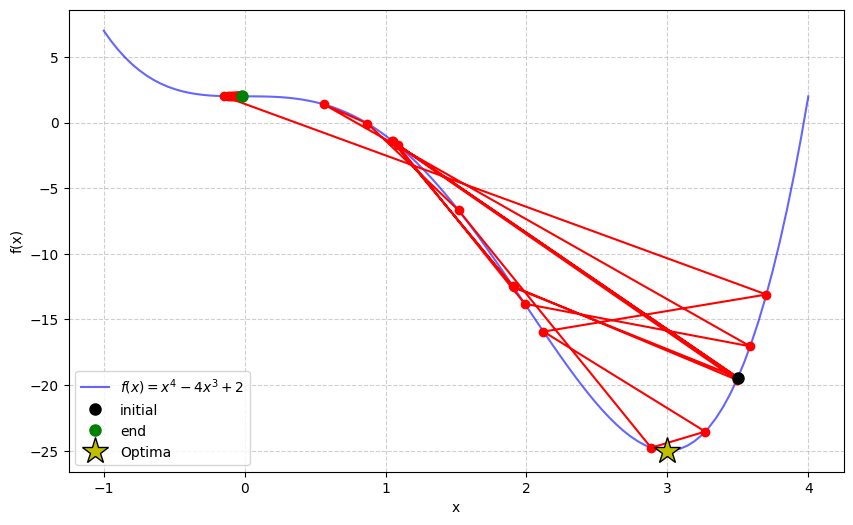

In [24]:
init_point = 3.5
lr = 0.1
epochs = 50
x_path = simple_GD(init_point, lr, epochs)
y_path = f(x_path)

plot_GD(x_path, y_path)

**Câu 2:** Cho hàm số có nhiều điểm cực tiểu $f(x) = x^4 - 5x^2 + x + 3$.

- Chạy Gradient Descent với 2 điểm khởi tạo khác nhau: `init_point = 0.0` và `init_point = 2.0`. Giữ nguyên lr = 0.05 và epochs = 50.

- Vẽ đồ thị cho cả hai trường hợp. Nhận xét và Giải thích.

In [25]:
def f(x):
    return x**4 - 5 * x**2 + x + 3

def gradient(x):
    return 4 * x**3 - 10 * x + 1

In [26]:
def plot_GD(x, y):

    x_vals = np.linspace(-3, 3, 100)
    y_vals = f(x_vals)

    # setup figure
    plt.figure(figsize=(10,6))
    plt.plot(x_vals, y_vals, label=r'$f(x) = x^4 - 5x^2 + x + 3$', color='blue', alpha=0.6)

    plt.plot(x, y, 'ro-', markersize=6)
    plt.plot(x[0], y[0], 'ko', label='initial', markersize=8)
    plt.plot(x[-1], y[-1], 'go', label='end', markersize=8)
    

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

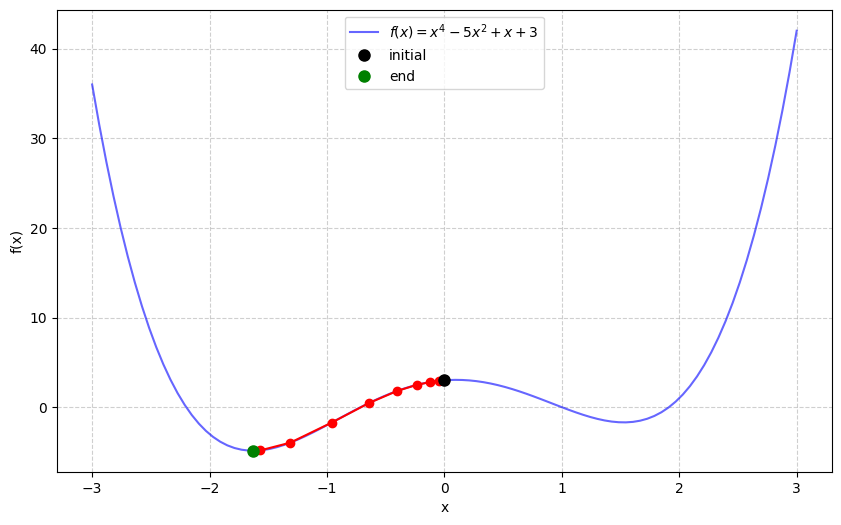

In [27]:
init_point = 0.0
lr = 0.05
epochs = 50
x_path = simple_GD(init_point, lr, epochs)
# print(x_path)
y_path = f(x_path)
#print(y_path)

plot_GD(x_path, y_path)

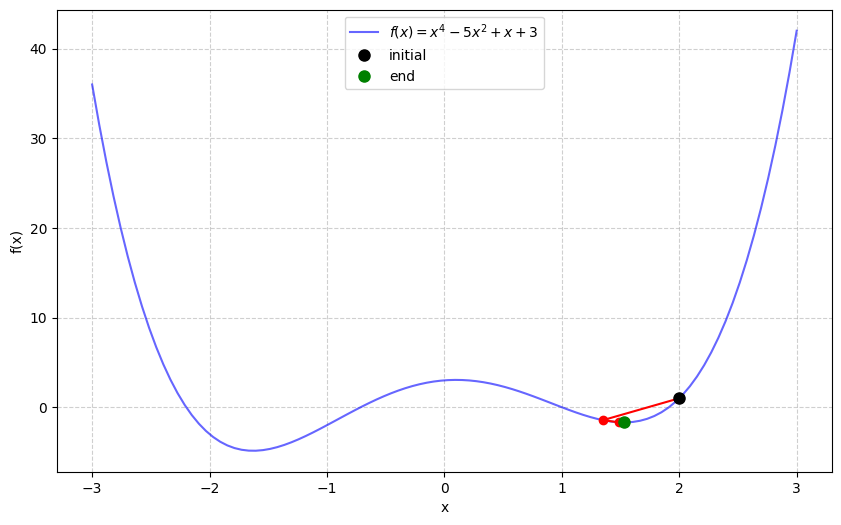

In [28]:
init_point = 2.0
lr = 0.05
epochs = 50
x_path = simple_GD(init_point, lr, epochs)
# print(x_path)
y_path = f(x_path)
#print(y_path)

plot_GD(x_path, y_path)

**Câu 3:** Trong phần ví dụ, thuật toán dừng lại khi chạy hết vòng lặp `epochs`. Thực tế, ta nên dừng sớm nếu hàm số không còn giảm đáng kể nữa:

- Thiết kế thuật toán GD với giá trị `epsilon`. Thuật toán sẽ chủ động `break` khỏi vòng lặp nếu trị tuyệt đối của gradient tại bước hiện tại nhỏ hơn hoặc bằng `epsilon`. Cho $\epsilon = 1e-4$

- Chạy với $f(x) = x^2 In ra số vòng lặp thực tế mà thuật toán đã dùng trước khi dừng. Đặt `epochs` = 50

In [29]:
def gradient_1d(x):
    return 2 * x

def simple_1dGD(x, lr, epochs, epsilon = 1e-4):
    x_path = [x]
    current_x = x
    count = 0

    for _ in range(epochs):
        count += 1
        grad = gradient_1d(current_x)
        current_x = current_x - lr * grad
        x_path.append(current_x)
        if abs(grad) <= epsilon:
            break

    print(count)
    return np.array(x_path)

In [30]:
init_point = 4.0
lr = 0.2
epochs = 50

x_path = simple_1dGD(init_point, lr, epochs)
print(x_path)

24
[4.00000000e+00 2.40000000e+00 1.44000000e+00 8.64000000e-01
 5.18400000e-01 3.11040000e-01 1.86624000e-01 1.11974400e-01
 6.71846400e-02 4.03107840e-02 2.41864704e-02 1.45118822e-02
 8.70712934e-03 5.22427761e-03 3.13456656e-03 1.88073994e-03
 1.12844396e-03 6.77066378e-04 4.06239827e-04 2.43743896e-04
 1.46246338e-04 8.77478026e-05 5.26486815e-05 3.15892089e-05
 1.89535254e-05]


**Câu 4:** Cho hàm số $f(x, y) = x^2 + 2y^2$.

- Viết hàm tính toán vector Gradient bao gồm đạo hàm riêng theo biến $x$ và đạo hàm riêng theo biến $y$.

- Chạy thuật toán Gradient Descent đa biến để cập nhật đồng thời cả $x$ và $y$ sau mỗi bước. Biết `x_init = 4.0, y_init = 4.0, lr = 0.1`. In ra tọa độ $(x, y)$ cuối cùng sau 30 epochs.

In [31]:
def f2(x, y):
    return x**2 + 2 * y**2

def GD2(x, y):
    return np.array([2 * x, 4 * y])

def gradient_descent(start_x, start_y, learning_rate, iterations):

    path = []
    current_pos = np.array([start_x, start_y])

    for i in range(iterations):
        path.append(current_pos.copy())
        grad = GD2(current_pos[0], current_pos[1])
        current_pos = current_pos - learning_rate * grad

    print(f"Epochs 30:Pos=({current_pos[0]:.4f}, {current_pos[1]:.4f}),"
    f"f(x,y)={f2d(current_pos[0], current_pos[1]):.4f}")
    return np.array(path)

In [32]:
initial_point = (4.0, 4.0)
lr = 0.1
epochs = 30

path_history = gradient_descent(initial_point[0],
                                initial_point[1],
                                lr,
                                epochs)

Epochs 30:Pos=(0.0050, 0.0000),f(x,y)=0.0000


**Câu 5:** Cho hàm số sau: $f(x, y, z) = x^3 - 3x + y^2 + z^2$.

- Sử dụng phương pháp Newton với các điểm khởi tạo `initial_point` cho trước như sau: $(2.0, 2.0, 2.0)$, $(0.0, 1.0, 1.0)$ và $(-2.0, 1.0, 1.0)$. Biết rằng số `epochs` cho trước là 10.

- Nhận xét kết quả diễn ra với 3 trường hợp nêu trên.

In [33]:
def GD(x, y, z):
    return np.array([3 * x**2 - 3, 2 * y, 2 * z])

def hessian(x):
    return np.array([[6 * x, 0, 0],
                    [0, 2, 0],
                    [0, 0, 2]])

def simple_newton(x, y, z, epochs):
    path = []
    current_pos = np.array([x, y, z])

    for i in range(epochs):
        path.append(current_pos)
        grad = GD(current_pos[0], current_pos[1], current_pos[2])
        hess = np.linalg.inv(hessian(current_pos[0]))

        current_pos = current_pos - np.dot(hess, grad)

    return np.array(path)

In [34]:
initial_point = (2.0, 2.0, 2.0)
epochs = 10

path_history = simple_newton(initial_point[0],
                            initial_point[1],
                            initial_point[2],
                            epochs)
print(path_history)

[[2.         2.         2.        ]
 [1.25       0.         0.        ]
 [1.025      0.         0.        ]
 [1.00030488 0.         0.        ]
 [1.00000005 0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]]


In [35]:
initial_point = (0.0, 1.0, 1.0)
epochs = 10

path_history = simple_newton(initial_point[0],
                            initial_point[1],
                            initial_point[2],
                            epochs)
print(path_history)

LinAlgError: Singular matrix

In [ ]:
initial_point = (-2.0, 1.0, 1.0)
epochs = 10

path_history = simple_newton(initial_point[0],
                            initial_point[1],
                            initial_point[2],
                            epochs)
print(path_history)

[[-2.          1.          1.        ]
 [-1.25        0.          0.        ]
 [-1.025       0.          0.        ]
 [-1.00030488  0.          0.        ]
 [-1.00000005  0.          0.        ]
 [-1.          0.          0.        ]
 [-1.          0.          0.        ]
 [-1.          0.          0.        ]
 [-1.          0.          0.        ]
 [-1.          0.          0.        ]]


**Câu 6:** Tìm một đường thẳng có phương trình $y_pred = m \cdot X + c$ sao cho đường thẳng này đi qua sát nhất với các điểm dữ liệu. Hàm đánh giá sai số (Hàm mất mát - MSE) được định nghĩa là:
$$
L(m, c) = \frac{1}{N} \sum_{i=1}^N (y_i - (m \cdot X_i + c))^2
$$

Hãy lập trình và so sánh 3 chiến lược Gradient Descent: Full Batch, Stochastic (SGD) và Mini-batch. Thực hiện câu hỏi này với các yêu cầu sau:




- Sinh $1000$ giá trị đầu vào $X$ ngẫu nhiên theo phân bố đều trong khoảng $[0,2]$. Tạo biến mục tiêu $y = 4 + 3x + ϵ$ với $\epsilon$ = `np.random.randn(1000,1)`. Lưu ý sử dụng `np.random.seed(42)` để kết quả đồng nhất giữa các bài.

- Tạo một hàm `minibatch_gradient_descent` với 3 kịch bản batchsize tương ứng với:
    - SGD : `batch_size` = $1$
    - GD: `batch_size` = `len(X)`
    - Mini-batch GD: `batch_size` = $32$

- Chạy 3 kịch bản nêu trên với `epochs = 50` và `lr = 0.01`

- Thực hiện vẽ một đồ thị Line Plot hiển thị sự thay đổi của hàm mất mát theo : số lần cập nhật trọng số (`iterations` với `max_iters` nên trực quan nên là 100-150)  cho cả 3 kịch bản trên cùng một trục tọa độ. Nêu nhận xét của bản thân.

- In ra trọng số của mô hình

- Lưu ý rằng:
    - Khác với GD, hai thuật toán còn lại cần phải xáo trộn `X` và `Y` đầu mỗi `epoch`.

    - SGD được cập nhật qua mỗi điểm dữ liệu còn mini-batch GD được cập nhật sau mỗi `batch` còn GD được cập nhật sau khi duyệt qua toàn bộ dữ liệu.



In [ ]:
import matplotlib.pyplot as plt
np.random.seed(42)
X = np.random.uniform(0, 2, 1000)
y = 4 + 3 * X + np.random.randn(1000, 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + np.random.randn(1000, 1)

def minibatch_gradient_descent(X, y, lr, epochs, batch_size):
    m = 0.0
    c = 0.0
    N = len(X)
    loss_history = []
    
    for epoch in range(epochs):
        if batch_size < N:
            indices = np.random.permutation(N)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
        else:
            X_shuffled = X
            y_shuffled = y
            
        for i in range(0, N, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            n_batch = len(X_batch)
            
            y_pred = m * X_batch + c

            dm = (-2/n_batch) * np.sum(X_batch * (y_batch - y_pred))
            dc = (-2/n_batch) * np.sum(y_batch - y_pred)

            m = m - lr * dm
            c = c - lr * dc

            y_pred_all = m * X + c
            loss = np.mean((y - y_pred_all)**2)
            loss_history.append(loss)
            
    return m, c, loss_history


In [ ]:
epochs = 50
lr = 0.01

m_sgd, c_sgd, loss_sgd = minibatch_gradient_descent(X, y, lr, epochs, batch_size=1)
m_gd, c_gd, loss_gd = minibatch_gradient_descent(X, y, lr, epochs, batch_size=len(X))
m_mini, c_mini, loss_mini = minibatch_gradient_descent(X, y, lr, epochs, batch_size=32)

print("(m, c) : (3, 4)")
print(f"Full Batch: m = {m_gd:.4f}, c = {c_gd:.4f}")
print(f"StochasticGD:   m = {m_sgd:.4f}, c = {c_sgd:.4f}")
print(f"Mini-batchGD:   m = {m_mini:.4f}, c = {c_mini:.4f}")

(m, c) : (3, 4)
Full Batch: m = 3.2065, c = 2.9957
StochasticGD:   m = 2.8920, c = 4.1447
Mini-batchGD:   m = 2.9239, c = 4.1721


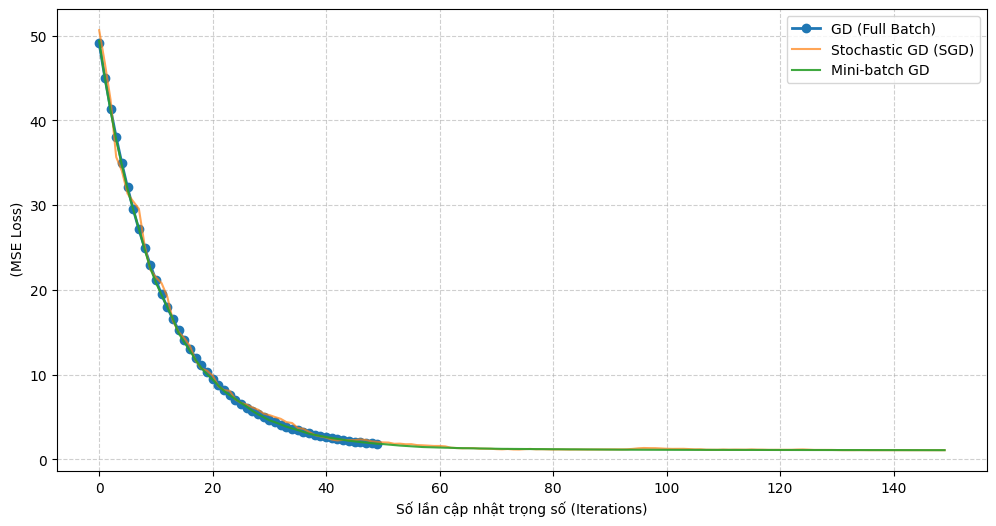

In [ ]:
plt.figure(figsize=(12, 6))
max_iters = 150

plt.plot(loss_gd[:max_iters], 'o-', label='GD (Full Batch)', linewidth=2)
plt.plot(loss_sgd[:max_iters], '-', label='Stochastic GD (SGD)', alpha=0.7)
plt.plot(loss_mini[:max_iters], '-', label='Mini-batch GD', alpha=0.9)

plt.xlabel('Iterations')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Câu 7:** Giống như câu 6 , tuy nhiên lần này ta có biến mục tiêu
$$
y = 4 + 3x_1 - 2x_2 + 5x_3 + \epsilon
$$

Khác với trường hợp đơn biến, bài toán đa biến cần một số lưu ý sau:

- Phương trình dự đoán sẽ có dạng: $y_{pred} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$
- Gọi $Error = y_{pred} - y_{batch}$. Tại mỗi bước tính toán trên một batch (có kích thước $N_{batch}$), đạo hàm của từng tham số được tính bằng công thức trung bình sau:
  - $dw_1 = \frac{2}{N_{batch}} \sum (Error \cdot x_1)$
  - $dw_2 = \frac{2}{N_{batch}} \sum (Error \cdot x_2)$
  - $dw_3 = \frac{2}{N_{batch}} \sum (Error \cdot x_3)$
  - $db = \frac{2}{N_{batch}} \sum (Error)$


In [ ]:
np.random.seed(42)
N = 1000
X1 = np.random.uniform(0, 2, (N, 1))
X2 = np.random.uniform(0, 2, (N, 1))
X3 = np.random.uniform(0, 2, (N, 1))

epsilon = np.random.randn(N, 1)
y = 4 + 3*X1 - 2*X2 + 5*X3 + epsilon
 
X = np.hstack((X1, X2, X3))

def minibatch_gradient_descent_multi(X, y, lr, epochs, batch_size):

    w = np.zeros((3, 1))
    b = 0.0
    N_samples = len(X)
    loss_history = []
    
    for epoch in range(epochs):
        if batch_size < N_samples:
            indices = np.random.permutation(N_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
        else:
            X_shuffled = X
            y_shuffled = y
            
        for i in range(0, N_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]  
            y_batch = y_shuffled[i:i+batch_size]   
            N_batch = len(X_batch)

            y_pred = X_batch.dot(w) + b

            Error = y_pred - y_batch

            dw = (2 / N_batch) * (X_batch.T.dot(Error))
            db = (2 / N_batch) * np.sum(Error)

            w = w - lr * dw
            b = b - lr * db

            y_pred_all = X.dot(w) + b
            mse = np.mean((y - y_pred_all)**2)
            loss_history.append(mse)
            
    return w, b, loss_history


In [ ]:
epochs = 50
lr = 0.01

w_sgd, b_sgd, loss_sgd = minibatch_gradient_descent_multi(X, y, lr, epochs, batch_size=1)
w_gd, b_gd, loss_gd = minibatch_gradient_descent_multi(X, y, lr, epochs, batch_size=len(X))
w_mini, b_mini, loss_mini = minibatch_gradient_descent_multi(X, y, lr, epochs, batch_size=32)

print("Trọng số của các mô hình:")
print(f"Thực tế       : b = 4.00, w1 = 3.00, w2 = -2.00, w3 = 5.00")
print(f"GD (Full Batch): b = {b_gd:.2f}, w1 = {w_gd[0][0]:.2f}, w2 = {w_gd[1][0]:.2f}, w3 = {w_gd[2][0]:.2f}")
print(f"Stochastic GD:   b = {b_sgd:.2f}, w1 = {w_sgd[0][0]:.2f}, w2 = {w_sgd[1][0]:.2f}, w3 = {w_sgd[2][0]:.2f}")
print(f"Mini-batch GD:   b = {b_mini:.2f}, w1 = {w_mini[0][0]:.2f}, w2 = {w_mini[1][0]:.2f}, w3 = {w_mini[2][0]:.2f}")

Trọng số của các mô hình:
Thực tế       : b = 4.00, w1 = 3.00, w2 = -2.00, w3 = 5.00
GD (Full Batch): b = 2.41, w1 = 2.66, w2 = 1.32, w3 = 3.31
Stochastic GD:   b = 4.09, w1 = 2.97, w2 = -1.79, w3 = 5.16
Mini-batch GD:   b = 3.95, w1 = 2.97, w2 = -2.02, w3 = 5.09


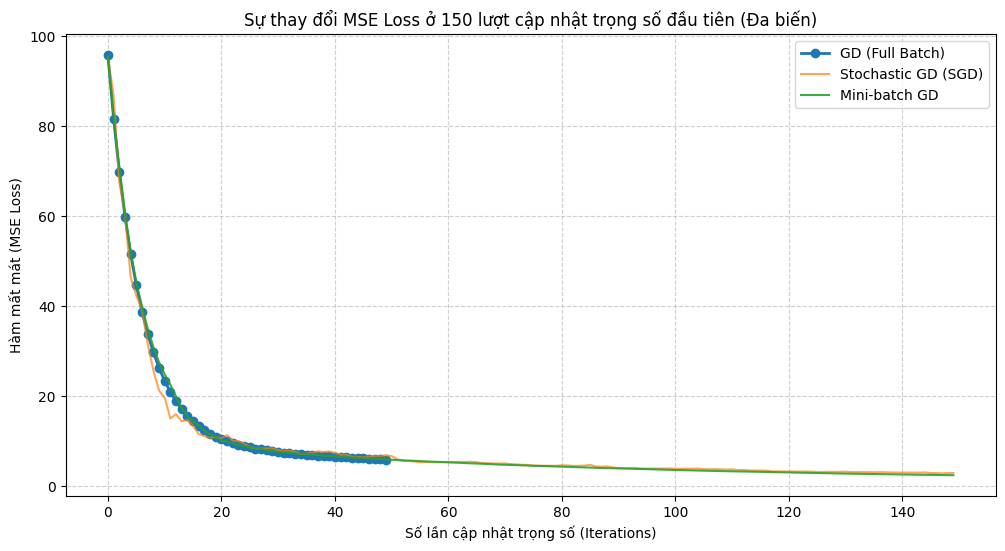

In [ ]:
plt.figure(figsize=(12, 6))
max_iters = 150

plt.plot(loss_gd[:max_iters], 'o-', label='GD (Full Batch)', linewidth=2)
plt.plot(loss_sgd[:max_iters], '-', label='Stochastic GD (SGD)', alpha=0.7)
plt.plot(loss_mini[:max_iters], '-', label='Mini-batch GD', alpha=0.9)

plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Đa biến')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()